In [1]:
# Basic imports 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from IPython.display import Video

# scikit-tda imports..... Install all with -> pip install scikit-tda
#--- this is the main persistence computation workhorse
import ripser
# from persim import plot_diagrams
import persim
# import persim.plot

# teaspoon imports...... Install with -> pip install teaspoon
#---these are for generating data and some drawing tools 
import teaspoon.MakeData.PointCloud as makePtCloud
import teaspoon.TDA.Draw as Draw

#---these are for generating time series network examples
from teaspoon.SP.network import ordinal_partition_graph
from teaspoon.TDA.PHN import PH_network
from teaspoon.SP.network_tools import make_network
from teaspoon.parameter_selection.MsPE import MsPE_tau
import teaspoon.MakeData.DynSysLib.DynSysLib as DSL

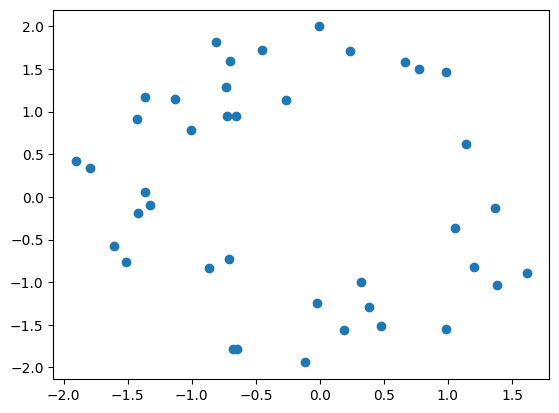

In [43]:
r = 1
R = 2
P = makePtCloud.Annulus(N=40, r=r, R=R, seed=None) # teaspoon data generation
plt.scatter(P[:,0],P[:,1])
# print(P)
# print(type(P))
# print(P.shape)

In [44]:
# Some quick code to draw stuff without showing all the matplotlib junk in the slides everytime. 

def drawTDAtutorial(P,diagrams, R = 2):
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize = (20,5))

    # Draw point cloud 
    plt.sca(axes[0])
    plt.title('Point Cloud')
    plt.scatter(P[:,0],P[:,1])

    # Draw diagrams
    plt.sca(axes[1])
    plt.title('0-dim Diagram')
    Draw.drawDgm(diagrams[0])

    plt.sca(axes[2])
    plt.title('1-dim Diagram')
    Draw.drawDgm(diagrams[1])
    plt.axis([0,R,0,R])

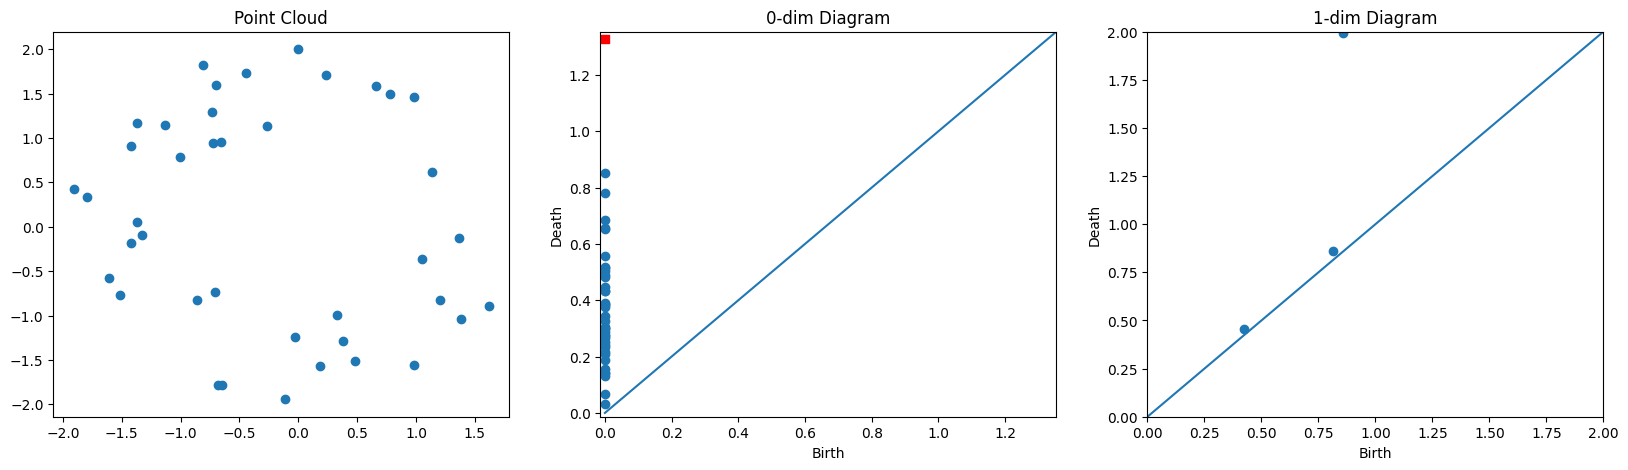

In [45]:
diagrams = ripser.ripser(P)['dgms']

# Draw stuff
drawTDAtutorial(P,diagrams)  # Script included in notebook for drawing

In [11]:
# Some discussion of how diagrams are stored 
data = ripser.ripser(P)
# print(data.keys())
# print(data['dgms'])
data['dgms'][1]
# len(data['dgms'])

array([[1.0933795 , 2.08371687]])

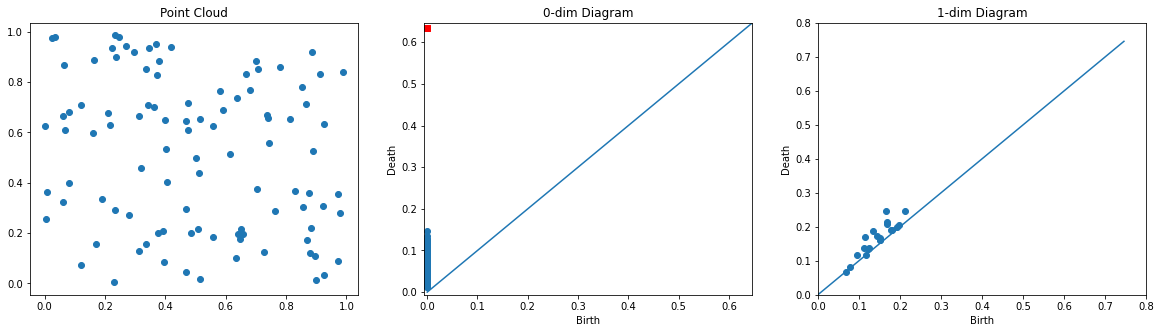

In [12]:
P = makePtCloud.Cube()
diagrams = ripser.ripser(P)['dgms']

# Draw stuff
drawTDAtutorial(P,diagrams,R=0.8) # Script for drawing everything, code included in notebook


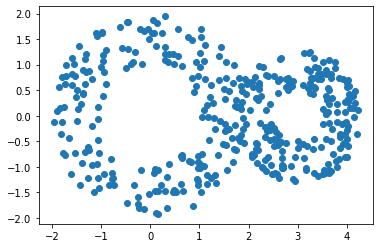

In [13]:
# Make a quick double annulus

def DoubleAnnulus(r1 = 1, R1 = 2, r2 = .8, R2 = 1.3, xshift = 3):
    P = makePtCloud.Annulus(r = r1, R = R1)
    Q = makePtCloud.Annulus(r = r2, R = R2)
    Q[:,0] = Q[:,0] + xshift
    P = np.concatenate((P, Q) )
    return(P)

P = DoubleAnnulus(r1 = 1, R1 = 2, r2 = .5, R2 = 1.3, xshift = 3) 
plt.scatter(P[:,0], P[:,1])

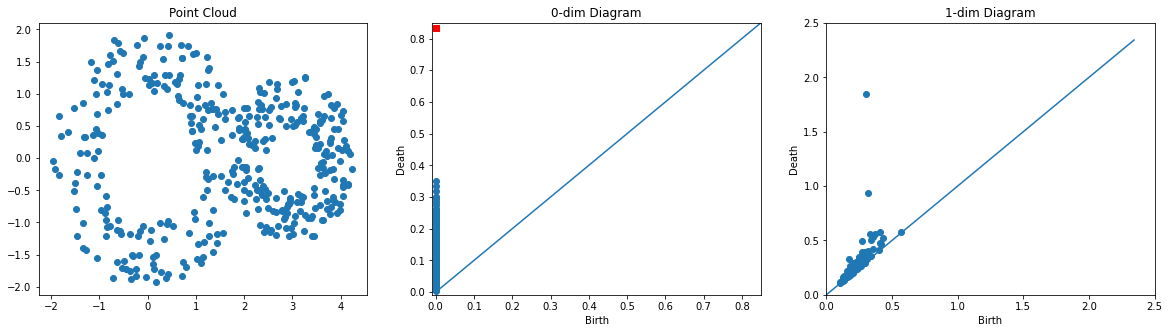

In [14]:
P = DoubleAnnulus(r1 = 1, R1 = 2, r2 = .5, R2 = 1.3, xshift = 3) # Code included in notebook
diagrams = ripser.ripser(P)['dgms']

# Draw stuff
drawTDAtutorial(P,diagrams,R=2.5) # Script for drawing everything, code included in notebook

In [15]:
# Generate the distance matrix from the previous example
D = np.array([[0, 1, np.inf, np.inf, 6],  [0, 0, 5, np.inf, np.inf],  [0, 0, 0, 2, 4],  [0, 0, 0, 0, 3],  [0, 0, 0, 0, 0]])
D = D+D.T
print(D)

[[ 0.  1. inf inf  6.]
 [ 1.  0.  5. inf inf]
 [inf  5.  0.  2.  4.]
 [inf inf  2.  0.  3.]
 [ 6. inf  4.  3.  0.]]


In [16]:
diagrams = ripser.ripser(D, distance_matrix=True, maxdim=1)['dgms']
print('0-Dim Diagram')
print(diagrams[0])
print('1-Dim Diagram')
print(diagrams[1])

0-Dim Diagram
[[ 0.  1.]
 [ 0.  2.]
 [ 0.  3.]
 [ 0.  5.]
 [ 0. inf]]
1-Dim Diagram
[[ 6. inf]]


In [17]:
# Drawing script for weighted graph
def drawGraphEx(G):
    #draw it!

    pos = nx.spring_layout(G)  # positions for all nodes - seed for reproducibility

    # nodes
    nx.draw_networkx_nodes(G, pos, node_size=70)

    # edges
    nx.draw_networkx_edges(G, pos,  width=2)
    # nx.draw_networkx_edges(
    #     G, pos, edgelist=esmall, width=6, alpha=0.5, edge_color="b", style="dashed"
    # )

    # labels
    # nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif")
    edge_labels=nx.draw_networkx_edge_labels(G,pos,edge_labels=nx.get_edge_attributes(G, 'weight'))

There are 14 edges.


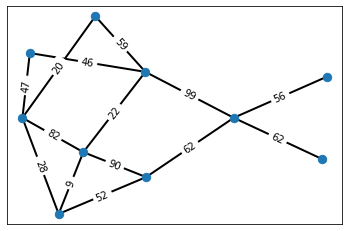

In [18]:
n = 10
p = .3

# Generate random graph 
G = nx.erdos_renyi_graph(n, p, seed=None, directed=False)

m = len(G.edges)
print('There are', m,'edges.')

# Generate random edge weights in the interval [0,maxWeight]
maxWeight = 100
weights = np.random.randint(maxWeight, size = m)

for i, e in enumerate(G.edges()):
    G[e[0]][e[1]] ['weight'] = weights[i]
    
drawGraphEx(G)

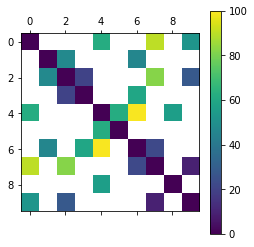

In [19]:
A = nx.adjacency_matrix(G, weight = 'weight')
A = A.todense() # Turn into dense matrix for ease of messing with it
A = np.array(A) # Apparently I need to hand scikit-tda an array instead of a matrix, don't know why
A = A.astype('float64') # Needed to let me put in np.inf
A[ np.where(A == 0)] = np.inf
np.fill_diagonal(A,0)

im = plt.matshow(A, vmax = 100) # Note the np.inf values show up as white
plt.colorbar(im)

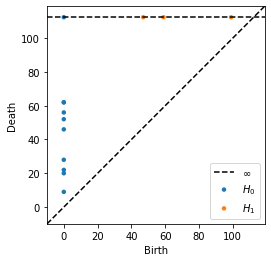

In [20]:
diagrams = ripser.ripser(A, distance_matrix=True)['dgms']
persim.plot_diagrams(diagrams)
# print(diagrams)
# print(diagrams)

In [21]:
Video("figures/OrdinalPartitionNetworkExample_AudunMyers.mp4", width = 1000)

ValueError: To embed videos, you must pass embed=True (this may make your notebook files huge)
Consider passing Video(url='...')

In [22]:
# Code to draw the next example later, here so it doesn't end up in a slide
def drawNetworkExample(gs,G,diagram):
    TextSize = 14
    plt.figure(2)
    plt.figure(figsize=(8,8))
    gs = gridspec.GridSpec(4, 2)

    ax = plt.subplot(gs[0:2, 0:2]) #plot time series
    plt.title('Time Series', size = TextSize)
    plt.plot(ts, 'k')
    plt.xticks(size = TextSize)
    plt.yticks(size = TextSize)
    plt.xlabel('$t$', size = TextSize)
    plt.ylabel('$x(t)$', size = TextSize)
    plt.xlim(0,len(ts))

    ax = plt.subplot(gs[2:4, 0])
    plt.title('Network', size = TextSize)
    nx.draw(G, pos, with_labels=False, font_weight='bold', node_color='blue',
            width=1, font_size = 10, node_size = 30)

    ax = plt.subplot(gs[2:4, 1])
    plt.title('Persistence Diagram', size = TextSize)
    MS = 3
    top = max(diagram[1].T[1])
    plt.plot([0,top*1.25],[0,top*1.25],'k--')
    plt.yticks( size = TextSize)
    plt.xticks(size = TextSize)
    plt.xlabel('Birth', size = TextSize)
    plt.ylabel('Death', size = TextSize)
    plt.plot(diagram[1].T[0],diagram[1].T[1] ,'go', markersize = MS+2)
    plt.xlim(0,top*1.25)
    plt.ylim(0,top*1.25)

    plt.subplots_adjust(hspace= 0.8)
    plt.subplots_adjust(wspace= 0.35)
    plt.show()
    
def drawThisDiagram(diagram):
    TextSize = 14
    plt.title('Persistence Diagram', size = TextSize)
    MS = 3
    top = max(diagram[1].T[1])
    plt.plot([0,top*1.25],[0,top*1.25],'k--')
    plt.yticks( size = TextSize)
    plt.xticks(size = TextSize)
    plt.xlabel('Birth', size = TextSize)
    plt.ylabel('Death', size = TextSize)
    plt.plot(diagram[1].T[0],diagram[1].T[1] ,'go', markersize = MS+2)
    plt.xlim(0,top*1.25)
    plt.ylim(0,top*1.25)

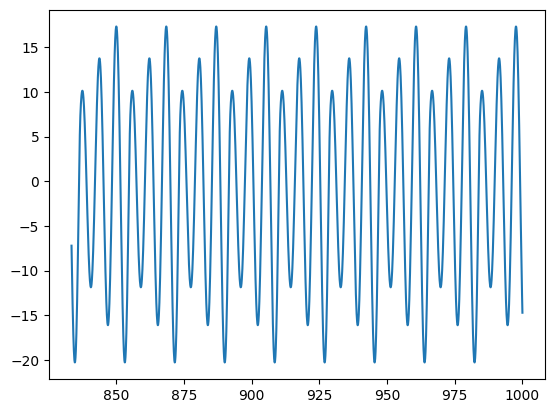

In [23]:
#generate time series
system = 'rossler'
dynamic_state = 'periodic'
t, solution = DSL.DynamicSystems(system, dynamic_state)
ts = solution[1]

plt.plot(t,ts)

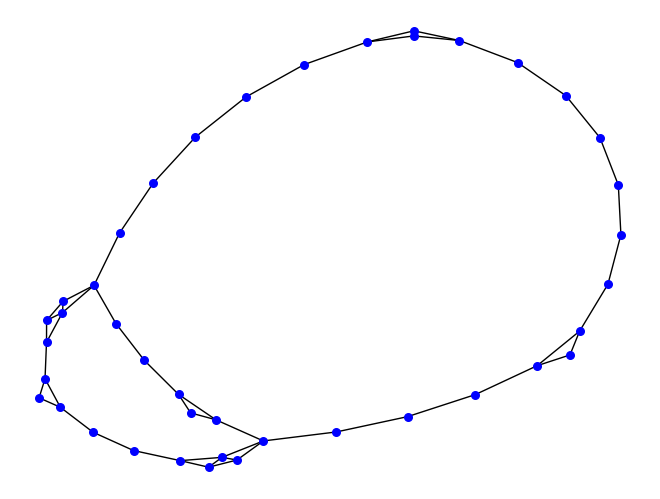

In [24]:
#Get appropriate dimension and delay parameters for permutations
tau = int(MsPE_tau(ts))
n = 5

#create adjacency matrix, this
A = ordinal_partition_graph(ts, n, tau)

#get networkx representation of network for plotting
G, pos = make_network(A, position_iterations = 2000, remove_deg_zero_nodes = True)

nx.draw(G, pos, with_labels=False, font_weight='bold', node_color='blue',
            width=1, font_size = 10, node_size = 30)

<Figure size 640x480 with 0 Axes>

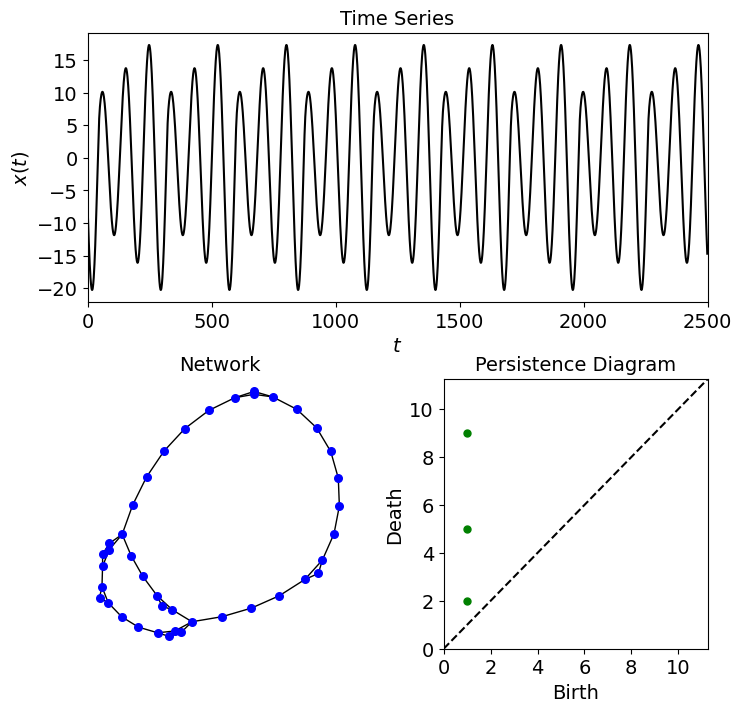

In [25]:
#create distance matrix and calculate persistence diagram
D, diagram = PH_network(A, method = 'unweighted', distance = 'shortest_path')
# print('1-D Persistent Homology (loops): \n', diagram[1])
drawNetworkExample(ts,G,diagram)

In [26]:
#generate time series
system = 'rossler'
dynamic_state = 'chaotic'
t, solution = DSL.DynamicSystems(system, dynamic_state)
ts = solution[1]

#Get appropriate dimension and delay parameters for permutations
tau = int(MsPE_tau(ts))
n = 5

#create adjacency matrix, this
A = ordinal_partition_graph(ts, n, tau)

#get networkx representation of network for plotting
G, pos = make_network(A, position_iterations = 2000, remove_deg_zero_nodes = True)

#create distance matrix and calculate persistence diagram
D, diagram = PH_network(A, method = 'unweighted', distance = 'shortest_path')
# print('1-D Persistent Homology (loops): \n', diagram[1])


<Figure size 640x480 with 0 Axes>

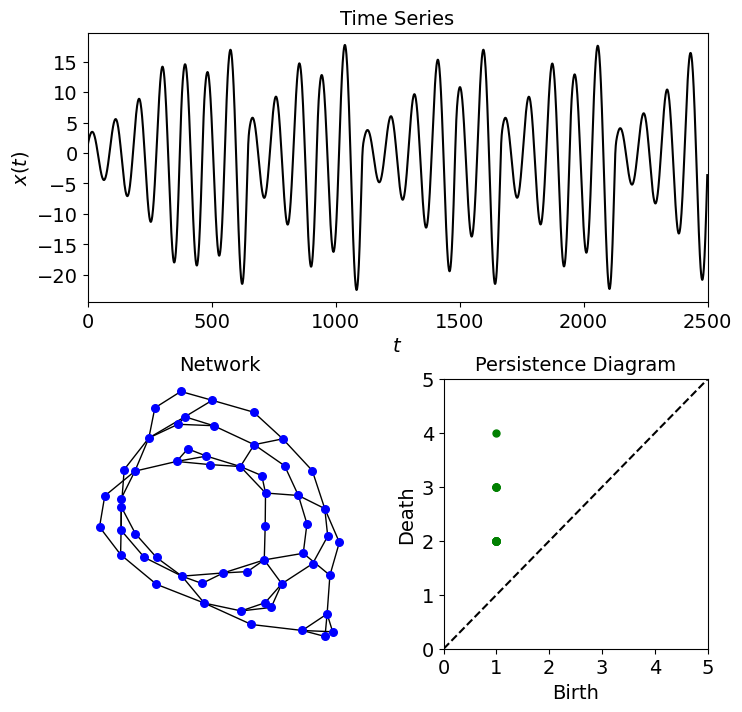

In [27]:
drawNetworkExample(ts,G,diagram)